# LSTM for Character-Level Language Modeling

This notebook implements an LSTM for character-level language modeling and explores key concepts:

1. **LSTM Implementation** - Long Short-Term Memory networks for sequence modeling
2. **Character-Level Modeling** - Predict next character given previous characters
3. **Teacher Forcing** - Training technique using ground truth inputs
4. **Exposure Bias** - Problem when training and inference differ
5. **Gradient Clipping** - Technique to prevent exploding gradients

## Goals
- Implement LSTM for character-level text generation
- Understand and demonstrate teacher forcing
- Observe exposure bias in action
- Apply gradient clipping for stable training
- Generate text samples from trained models


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import string
import random
from collections import Counter

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')


Using device: cpu


## 1. Understanding Key Concepts

### Teacher Forcing
During training, instead of using the model's own predictions as input for the next time step, we use the ground truth (actual next character). This speeds up training but can lead to exposure bias.

### Exposure Bias
When training uses ground truth (teacher forcing) but inference uses model predictions, there's a mismatch. The model never sees its own mistakes during training, so it may struggle at inference time.

### Gradient Clipping
RNNs/LSTMs can suffer from exploding gradients. Gradient clipping limits the gradient norm to prevent this, making training more stable.


## 2. Prepare Character-Level Dataset

We'll use a text corpus and convert it to character-level sequences.


In [2]:
# Sample text corpus (you can replace with any text file)
text_corpus = """
The quick brown fox jumps over the lazy dog. 
Machine learning is a subset of artificial intelligence.
Deep learning uses neural networks with multiple layers.
Natural language processing helps computers understand human language.
Recurrent neural networks process sequences of data.
Long short-term memory networks can remember information for long periods.
Character-level models work at the level of individual characters.
Text generation models can create new text based on training data.
"""

# Or load from a file (uncomment if you have a text file)
# with open('your_text_file.txt', 'r', encoding='utf-8') as f:
#     text_corpus = f.read()

# Create character vocabulary
chars = sorted(list(set(text_corpus)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars[:50])}...")

# Create character-to-index and index-to-character mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"\nSample mappings:")
print(f"'T' -> {char_to_idx['T']}")
print(f"{char_to_idx['T']} -> '{idx_to_char[char_to_idx['T']]}'")


Vocabulary size: 37
Characters: 
 -.CDLMNRTabcdefghijklmnopqrstuvwxyz...

Sample mappings:
'T' -> 10
10 -> 'T'


In [3]:
class CharDataset(Dataset):
    """Dataset for character-level language modeling"""
    def __init__(self, text, char_to_idx, seq_length=50):
        self.text = text
        self.char_to_idx = char_to_idx
        self.seq_length = seq_length
        
        # Convert text to indices
        self.data = [char_to_idx[ch] for ch in text if ch in char_to_idx]
        
    def __len__(self):
        return len(self.data) - self.seq_length
    
    def __getitem__(self, idx):
        # Input sequence: characters from idx to idx+seq_length-1
        # Target sequence: characters from idx+1 to idx+seq_length (shifted by 1)
        input_seq = torch.tensor(self.data[idx:idx+self.seq_length], dtype=torch.long)
        target_seq = torch.tensor(self.data[idx+1:idx+self.seq_length+1], dtype=torch.long)
        return input_seq, target_seq

# Create dataset
seq_length = 50
dataset = CharDataset(text_corpus, char_to_idx, seq_length=seq_length)

# Split into train and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Sequence length: {seq_length}")
print(f"Batch size: {batch_size}")

# Show a sample
sample_input, sample_target = train_dataset[0]
print(f"\nSample input (first 20 chars): {''.join([idx_to_char[i.item()] for i in sample_input[:20]])}")
print(f"Sample target (first 20 chars): {''.join([idx_to_char[i.item()] for i in sample_target[:20]])}")


Training samples: 355
Validation samples: 89
Sequence length: 50
Batch size: 32

Sample input (first 20 chars): current neural netwo
Sample target (first 20 chars): urrent neural networ


## 3. LSTM Model Implementation

We'll implement a character-level LSTM that can be trained with or without teacher forcing.


In [4]:
class CharLSTM(nn.Module):
    """
    Character-level LSTM language model.
    """
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.2):
        super(CharLSTM, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Embedding layer: converts character indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Output layer: maps hidden state to vocabulary
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, hidden=None):
        """
        Forward pass.
        
        Args:
            x: Input tensor of shape (batch_size, seq_length)
            hidden: Tuple of (h_n, c_n) hidden states
        
        Returns:
            output: Logits of shape (batch_size, seq_length, vocab_size)
            hidden: Updated hidden states
        """
        # Embedding: (batch_size, seq_length) -> (batch_size, seq_length, embedding_dim)
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        # LSTM: (batch_size, seq_length, embedding_dim) -> (batch_size, seq_length, hidden_dim)
        lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = self.dropout(lstm_out)
        
        # Output: (batch_size, seq_length, hidden_dim) -> (batch_size, seq_length, vocab_size)
        output = self.fc(lstm_out)
        
        return output, hidden
    
    def init_hidden(self, batch_size):
        """Initialize hidden states"""
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        return (h0, c0)
    
    def generate(self, start_string, length=100, temperature=1.0, top_k=None):
        """
        Generate text given a starting string.
        
        Args:
            start_string: Initial string to start generation
            length: Number of characters to generate
            temperature: Controls randomness (higher = more random)
            top_k: If set, only sample from top k most likely characters
        """
        self.eval()
        hidden = None
        
        # Convert start string to indices
        chars = [c for c in start_string if c in char_to_idx]
        if not chars:
            chars = [list(char_to_idx.keys())[0]]  # Fallback to first char
        
        input_seq = torch.tensor([[char_to_idx[c] for c in chars]], dtype=torch.long).to(device)
        generated = chars.copy()
        
        with torch.no_grad():
            # Process initial sequence
            for i in range(len(chars) - 1):
                output, hidden = self.forward(input_seq[:, i:i+1], hidden)
            
            # Generate new characters
            last_char = input_seq[:, -1:]
            for _ in range(length):
                output, hidden = self.forward(last_char, hidden)
                
                # Get logits for last character
                logits = output[0, -1, :] / temperature
                
                # Apply top-k filtering if specified
                if top_k is not None:
                    top_k_logits, top_k_indices = torch.topk(logits, top_k)
                    logits = torch.full_like(logits, float('-inf'))
                    logits[top_k_indices] = top_k_logits
                
                # Sample from distribution
                probs = F.softmax(logits, dim=-1)
                next_char_idx = torch.multinomial(probs, 1).item()
                
                generated.append(idx_to_char[next_char_idx])
                last_char = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
        
        return ''.join(generated)

# Create model
model = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 935,845


In [5]:
def train_with_teacher_forcing(model, train_loader, optimizer, criterion, device, clip_grad_norm=None):
    """
    Train with teacher forcing: always use ground truth as input.
    """
    model.train()
    total_loss = 0.0
    total_chars = 0
    
    for batch_input, batch_target in tqdm(train_loader, desc='Training', leave=False):
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass: use ground truth input (teacher forcing)
        # Input: batch_input (ground truth)
        # Target: batch_target (next character)
        output, _ = model(batch_input)
        
        # Reshape for loss calculation
        # output: (batch_size, seq_length, vocab_size)
        # target: (batch_size, seq_length)
        output = output.reshape(-1, output.size(-1))
        target = batch_target.reshape(-1)
        
        # Calculate loss
        loss = criterion(output, target)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (if specified)
        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        
        # Update weights
        optimizer.step()
        
        # Statistics
        total_loss += loss.item() * batch_input.size(0) * batch_input.size(1)
        total_chars += batch_input.size(0) * batch_input.size(1)
    
    return total_loss / total_chars


def evaluate(model, val_loader, criterion, device):
    """Evaluate model on validation set"""
    model.eval()
    total_loss = 0.0
    total_chars = 0
    
    with torch.no_grad():
        for batch_input, batch_target in tqdm(val_loader, desc='Evaluating', leave=False):
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)
            
            # Forward pass
            output, _ = model(batch_input)
            output = output.reshape(-1, output.size(-1))
            target = batch_target.reshape(-1)
            
            loss = criterion(output, target)
            total_loss += loss.item() * batch_input.size(0) * batch_input.size(1)
            total_chars += batch_input.size(0) * batch_input.size(1)
    
    return total_loss / total_chars


## 5. Training WITHOUT Teacher Forcing (Observing Exposure Bias)

When we don't use teacher forcing, the model uses its own predictions, which is closer to inference but can be slower to train and more unstable.


In [6]:
def train_without_teacher_forcing(model, train_loader, optimizer, criterion, device, clip_grad_norm=None):
    """
    Train without teacher forcing: use model's own predictions as input.
    This is slower but closer to inference, helping reduce exposure bias.
    """
    model.train()
    total_loss = 0.0
    total_chars = 0
    
    for batch_input, batch_target in tqdm(train_loader, desc='Training (no TF)', leave=False):
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)
        
        batch_size, seq_length = batch_input.size()
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Initialize hidden state
        hidden = model.init_hidden(batch_size)
        
        # Process sequence step by step, using model's own predictions
        loss = 0
        current_input = batch_input[:, 0:1]  # Start with first character
        
        for t in range(seq_length):
            # Forward pass one step
            output, hidden = model(current_input, hidden)
            
            # Calculate loss for this step
            step_output = output[:, -1, :]  # (batch_size, vocab_size)
            step_target = batch_target[:, t]  # (batch_size,)
            step_loss = criterion(step_output, step_target)
            loss += step_loss
            
            # Use model's prediction (or ground truth with some probability for stability)
            # For pure non-teacher-forcing, use prediction:
            if t < seq_length - 1:  # Don't need input for last step
                # Sample from output distribution
                probs = F.softmax(step_output, dim=-1)
                predicted = torch.multinomial(probs, 1)  # (batch_size, 1)
                current_input = predicted
        
        # Average loss over sequence
        loss = loss / seq_length
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        
        # Update weights
        optimizer.step()
        
        # Statistics
        total_loss += loss.item() * batch_size * seq_length
        total_chars += batch_size * seq_length
    
    return total_loss / total_chars


## 6. Training Loop: Compare Teacher Forcing vs No Teacher Forcing

Let's train two models and compare their behavior.


In [7]:
num_epochs = 20
learning_rate = 0.001
clip_grad_norm = 5.0  # Gradient clipping threshold

criterion = nn.CrossEntropyLoss()

# Model 1: With Teacher Forcing
print("=" * 70)
print("Training Model 1: WITH Teacher Forcing")
print("=" * 70)

model_tf = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2
).to(device)

optimizer_tf = optim.Adam(model_tf.parameters(), lr=learning_rate)

history_tf = {
    'train_loss': [],
    'val_loss': []
}

for epoch in range(num_epochs):
    train_loss = train_with_teacher_forcing(
        model_tf, train_loader, optimizer_tf, criterion, device, clip_grad_norm
    )
    val_loss = evaluate(model_tf, val_loader, criterion, device)
    
    history_tf['train_loss'].append(train_loss)
    history_tf['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\n" + "=" * 70)
print("Training Model 2: WITHOUT Teacher Forcing")
print("=" * 70)

# Model 2: Without Teacher Forcing
model_no_tf = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2
).to(device)

optimizer_no_tf = optim.Adam(model_no_tf.parameters(), lr=learning_rate)

history_no_tf = {
    'train_loss': [],
    'val_loss': []
}

for epoch in range(num_epochs):
    train_loss = train_without_teacher_forcing(
        model_no_tf, train_loader, optimizer_no_tf, criterion, device, clip_grad_norm
    )
    val_loss = evaluate(model_no_tf, val_loader, criterion, device)
    
    history_no_tf['train_loss'].append(train_loss)
    history_no_tf['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Training Model 1: WITH Teacher Forcing


Epoch 1/20: Train Loss: 3.3180, Val Loss: 3.0194


Epoch 2/20: Train Loss: 2.9738, Val Loss: 2.8169


Epoch 3/20: Train Loss: 2.6726, Val Loss: 2.3863


Epoch 4/20: Train Loss: 2.2261, Val Loss: 1.9452


...

Epoch 16/20: Train Loss: 3.0462, Val Loss: 3.0164


Epoch 17/20: Train Loss: 3.0460, Val Loss: 3.0162


Epoch 18/20: Train Loss: 3.0451, Val Loss: 3.0179


Epoch 19/20: Train Loss: 3.0443, Val Loss: 3.0170


Epoch 20/20: Train Loss: 3.0461, Val Loss: 3.0166


## 7. Visualize Training Curves


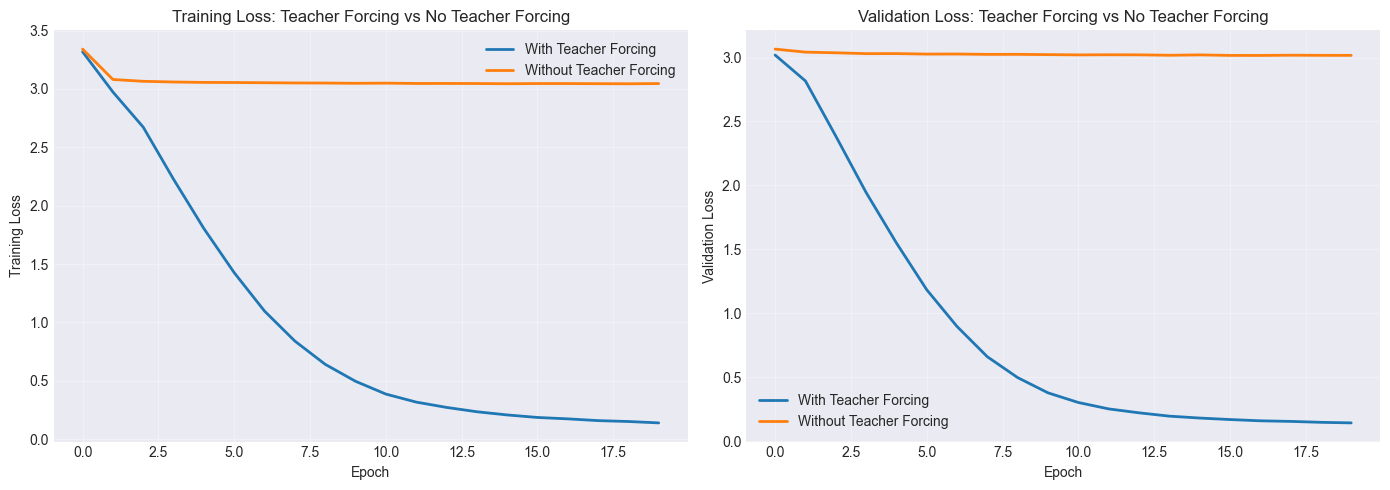

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(history_tf['train_loss'], label='With Teacher Forcing', linewidth=2)
axes[0].plot(history_no_tf['train_loss'], label='Without Teacher Forcing', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss: Teacher Forcing vs No Teacher Forcing')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(history_tf['val_loss'], label='With Teacher Forcing', linewidth=2)
axes[1].plot(history_no_tf['val_loss'], label='Without Teacher Forcing', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss: Teacher Forcing vs No Teacher Forcing')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Demonstrate Exposure Bias

Let's generate text from both models to see the difference. Exposure bias becomes apparent when the model makes a mistake early - with teacher forcing, it never saw its own mistakes during training.


In [9]:
# Generate text samples
start_string = "The quick brown"
generation_length = 100

print("=" * 70)
print("Text Generation Comparison")
print("=" * 70)

print(f"\nStarting string: '{start_string}'")
print(f"Generating {generation_length} characters...\n")

# Model with Teacher Forcing
generated_tf = model_tf.generate(start_string, length=generation_length, temperature=0.8)
print("Model trained WITH Teacher Forcing:")
print(f"'{generated_tf}'\n")

# Model without Teacher Forcing
generated_no_tf = model_no_tf.generate(start_string, length=generation_length, temperature=0.8)
print("Model trained WITHOUT Teacher Forcing:")
print(f"'{generated_no_tf}'\n")

# Try with a different starting string
start_string2 = "Machine learning"
print(f"\nStarting string: '{start_string2}'")
print(f"Generating {generation_length} characters...\n")

generated_tf2 = model_tf.generate(start_string2, length=generation_length, temperature=0.8)
print("Model trained WITH Teacher Forcing:")
print(f"'{generated_tf2}'\n")

generated_no_tf2 = model_no_tf.generate(start_string2, length=generation_length, temperature=0.8)
print("Model trained WITHOUT Teacher Forcing:")
print(f"'{generated_no_tf2}'\n")


Text Generation Comparison

Starting string: 'The quick brown'
Generating 100 characters...

Model trained WITH Teacher Forcing:
'The quick brown fox jumps over the lazy dog. 
Machine learning is a subset of artificial intelligence.
Deep learnin'

Model trained WITHOUT Teacher Forcing:
'The quick brownoereaest reoteghatslhranlw ioacaveolnlmaeo   lcetdnyta o enn lemmors eeaeh s N eeoln rnl ooNy nlggin'


Starting string: 'Machine learning'
Generating 100 characters...

Model trained WITH Teacher Forcing:
'Machine learning is a subset of artificial intelligence.
Deep learning uses neural networks process sequences of dat'

Model trained WITHOUT Teacher Forcing:
'Machine learningtt enurel oyte  nvs asehalt naoeno sdmuseiagueeorictkerht earl lgle  eiroisor ocnnnde eknta iki ints'



## 9. Gradient Clipping Analysis

Let's observe gradient norms during training to see the effect of gradient clipping.


Training model and tracking gradient norms...
Epoch 5: Avg grad norm before clip: 0.6069, after clip: 0.6069
Epoch 10: Avg grad norm before clip: 0.3629, after clip: 0.3629
Epoch 15: Avg grad norm before clip: 0.2022, after clip: 0.2022
Epoch 20: Avg grad norm before clip: 0.1775, after clip: 0.1775


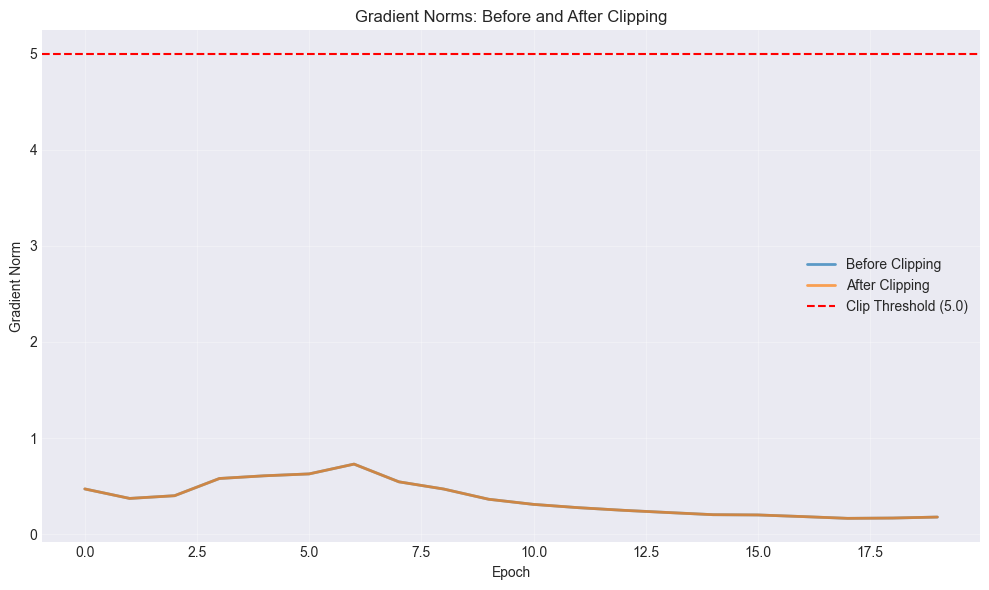


Gradient clipping threshold: 5.0
Max gradient norm before clipping: 0.7286
Max gradient norm after clipping: 0.7286
Number of times gradients were clipped: 0


In [10]:
def get_gradient_norm(model):
    """Calculate the gradient norm of all parameters"""
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# Train a model and track gradient norms
print("Training model and tracking gradient norms...")
model_grad = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2
).to(device)

optimizer_grad = optim.Adam(model_grad.parameters(), lr=learning_rate)

grad_norms_before_clip = []
grad_norms_after_clip = []
clip_threshold = 5.0

for epoch in range(num_epochs):
    epoch_grads_before = []
    epoch_grads_after = []
    
    for batch_input, batch_target in train_loader:
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)
        
        optimizer_grad.zero_grad()
        output, _ = model_grad(batch_input)
        output = output.reshape(-1, output.size(-1))
        target = batch_target.reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        
        # Get gradient norm BEFORE clipping
        grad_norm_before = get_gradient_norm(model_grad)
        epoch_grads_before.append(grad_norm_before)
        
        # Clip gradients
        torch.nn.utils.clip_grad_norm_(model_grad.parameters(), clip_threshold)
        
        # Get gradient norm AFTER clipping
        grad_norm_after = get_gradient_norm(model_grad)
        epoch_grads_after.append(grad_norm_after)
        
        optimizer_grad.step()
    
    grad_norms_before_clip.append(np.mean(epoch_grads_before))
    grad_norms_after_clip.append(np.mean(epoch_grads_after))
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Avg grad norm before clip: {grad_norms_before_clip[-1]:.4f}, "
              f"after clip: {grad_norms_after_clip[-1]:.4f}")

# Visualize gradient norms
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(grad_norms_before_clip, label='Before Clipping', linewidth=2, alpha=0.7)
ax.plot(grad_norms_after_clip, label='After Clipping', linewidth=2, alpha=0.7)
ax.axhline(y=clip_threshold, color='r', linestyle='--', label=f'Clip Threshold ({clip_threshold})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradient Norms: Before and After Clipping')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGradient clipping threshold: {clip_threshold}")
print(f"Max gradient norm before clipping: {max(grad_norms_before_clip):.4f}")
print(f"Max gradient norm after clipping: {max(grad_norms_after_clip):.4f}")
print(f"Number of times gradients were clipped: {sum(1 for b, a in zip(grad_norms_before_clip, grad_norms_after_clip) if b > clip_threshold)}")


Training with gradient clipping...



Training without gradient clipping...


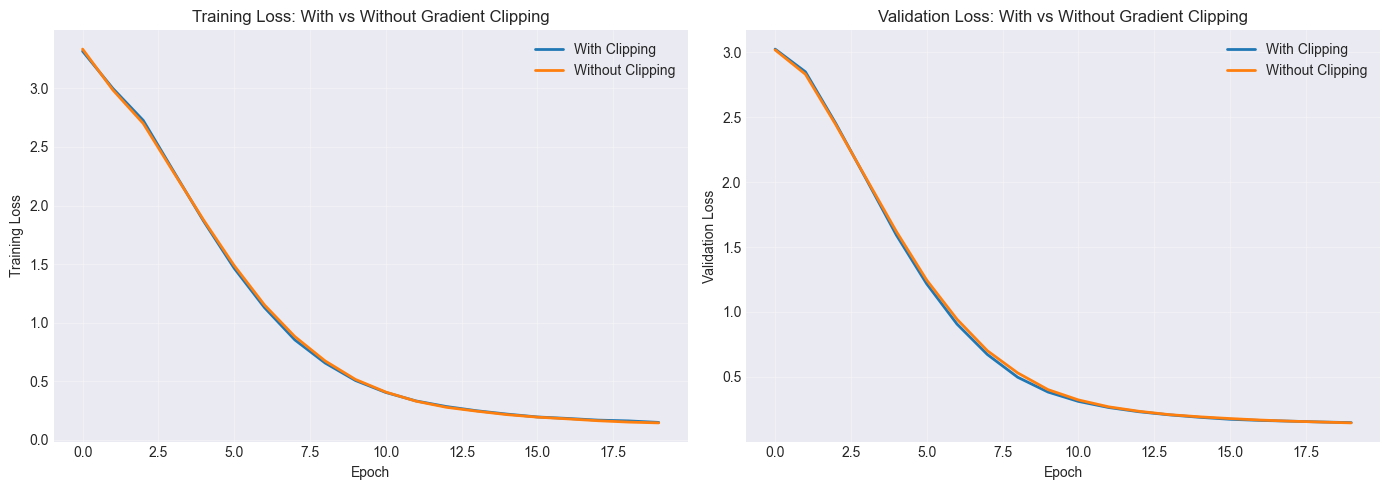

In [11]:
# Model with gradient clipping
print("Training with gradient clipping...")
model_with_clip = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2
).to(device)

optimizer_with_clip = optim.Adam(model_with_clip.parameters(), lr=learning_rate)
history_with_clip = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    train_loss = train_with_teacher_forcing(
        model_with_clip, train_loader, optimizer_with_clip, criterion, device, 
        clip_grad_norm=5.0
    )
    val_loss = evaluate(model_with_clip, val_loader, criterion, device)
    history_with_clip['train_loss'].append(train_loss)
    history_with_clip['val_loss'].append(val_loss)

# Model without gradient clipping
print("\nTraining without gradient clipping...")
model_no_clip = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2
).to(device)

optimizer_no_clip = optim.Adam(model_no_clip.parameters(), lr=learning_rate)
history_no_clip = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    train_loss = train_with_teacher_forcing(
        model_no_clip, train_loader, optimizer_no_clip, criterion, device, 
        clip_grad_norm=None  # No clipping
    )
    val_loss = evaluate(model_no_clip, val_loader, criterion, device)
    history_no_clip['train_loss'].append(train_loss)
    history_no_clip['val_loss'].append(val_loss)
    
    # Check for NaN (exploding gradients)
    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f"Training diverged at epoch {epoch+1} (NaN detected)")
        break

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with_clip['train_loss'], label='With Clipping', linewidth=2)
axes[0].plot(history_no_clip['train_loss'], label='Without Clipping', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss: With vs Without Gradient Clipping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_with_clip['val_loss'], label='With Clipping', linewidth=2)
axes[1].plot(history_no_clip['val_loss'], label='Without Clipping', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss: With vs Without Gradient Clipping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Key Insights and Summary

### Teacher Forcing
- **Pros**: Faster training, more stable gradients, easier to optimize
- **Cons**: Creates exposure bias - model never sees its own mistakes during training
- **Result**: Model may perform well during training but struggle at inference when it must use its own predictions

### Exposure Bias
- Occurs when there's a mismatch between training (uses ground truth) and inference (uses model predictions)
- Model trained with teacher forcing may make early mistakes that compound during generation
- Model trained without teacher forcing is more robust but slower to train

### Gradient Clipping
- Prevents exploding gradients in RNNs/LSTMs
- Clips gradient norm to a threshold (e.g., 5.0)
- Essential for stable training, especially for longer sequences
- Without clipping, gradients can grow exponentially and cause training to diverge

### Best Practices
1. **Use teacher forcing during training** for speed and stability
2. **Apply gradient clipping** (typically clip_norm = 1.0 to 10.0)
3. **Consider scheduled sampling** - gradually reduce teacher forcing probability during training
4. **Use beam search or top-k sampling** during inference for better generation quality
